In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
from collections import Counter

# Natural Language Processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [16]:
df = pd.read_csv('C:/Users/YEO/Downloads/sentimentdataset.csv')


print('✓ Dataset loaded successfully')
print(f'Total records: {len(df):,}')
print(f'Total features: {df.shape[1]}')
print(f'\nColumns: {list(df.columns)}')

✓ Dataset loaded successfully
Total records: 732
Total features: 15

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [17]:
#Show Data Frame Head

df.head(0)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour


In [18]:
# Dataset information

print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [ ]:
# Clean column names - remove leading/trailing whitespace

df['Sentiment'] = df['Sentiment'].str.strip()
df['Text'] = df['Text'].str.strip()
df['Platform'] = df['Platform'].str.strip()

In [21]:
# Sentiment distribution
sentiment_counts = df['Sentiment'].value_counts()
sentiment_percentages = (sentiment_counts / len(df)) * 100

print('Sentiment Distribution:')
print('='*50)
for sentiment, count in sentiment_counts.head(15).items():
    pct = sentiment_percentages[sentiment]
    print(f'{sentiment:20s}: {count:4d} ({pct:5.2f}%)')

print(f'\nTotal unique sentiments: {len(sentiment_counts)}')

Sentiment Distribution:
Positive            :   45 ( 6.15%)
Joy                 :   44 ( 6.01%)
Excitement          :   37 ( 5.05%)
Contentment         :   19 ( 2.60%)
Neutral             :   18 ( 2.46%)
Gratitude           :   18 ( 2.46%)
Curiosity           :   16 ( 2.19%)
Serenity            :   15 ( 2.05%)
Happy               :   14 ( 1.91%)
Nostalgia           :   11 ( 1.50%)
Despair             :   11 ( 1.50%)
Grief               :    9 ( 1.23%)
Awe                 :    9 ( 1.23%)
Sad                 :    9 ( 1.23%)
Hopeful             :    9 ( 1.23%)

Total unique sentiments: 191


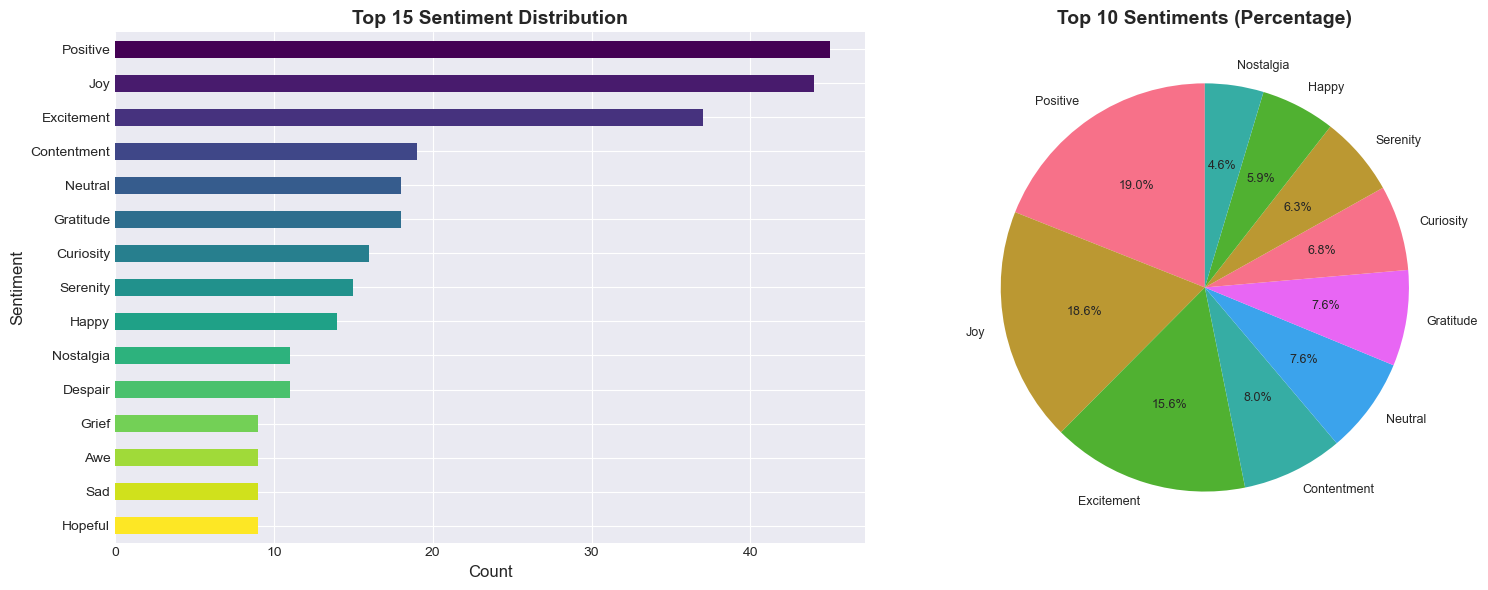

In [22]:
# Visualize top sentiments
top_sentiments = sentiment_counts.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
colors = plt.cm.viridis(np.linspace(0, 1, len(top_sentiments)))
top_sentiments.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Top 15 Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Sentiment', fontsize=12)
axes[0].invert_yaxis()

# Pie chart for top 10
top10 = sentiment_counts.head(10)
axes[1].pie(top10, labels=top10.index, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Top 10 Sentiments (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Platform Distribution:
Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64


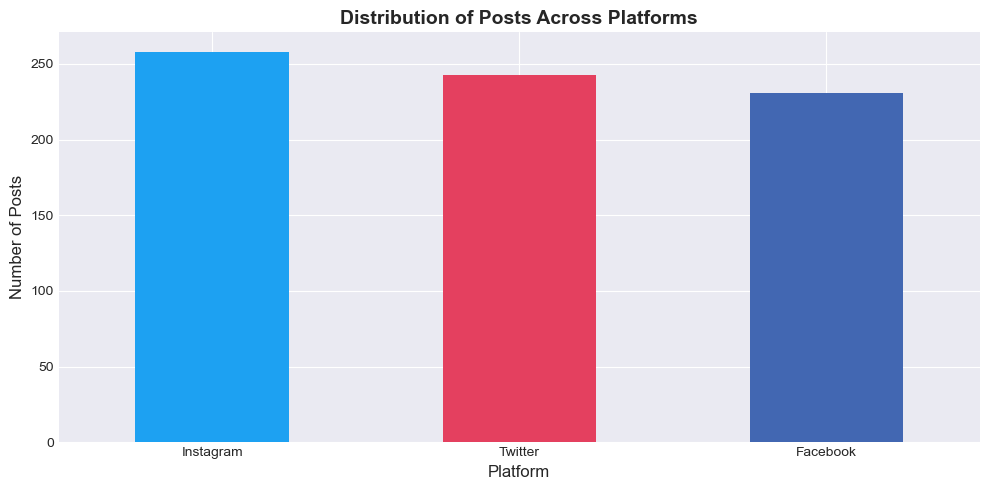

In [23]:
# Platform distribution
platform_counts = df['Platform'].value_counts()

print('Platform Distribution:')
print(platform_counts)

# Visualize
plt.figure(figsize=(10, 5))
platform_counts.plot(kind='bar', color=['#1DA1F2', '#E4405F', '#4267B2'])
plt.title('Distribution of Posts Across Platforms', fontsize=14, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Engagement by Top 10 Sentiments:
             Likes  Retweets
Sentiment                   
Contentment  51.37     25.79
Excitement   50.27     25.49
Joy          49.27     24.70
Gratitude    49.17     24.56
Happy        45.14     23.07
Curiosity    43.00     21.50
Serenity     42.40     21.13
Neutral      40.50     20.56
Positive     37.78     18.87
Nostalgia    36.36     18.00


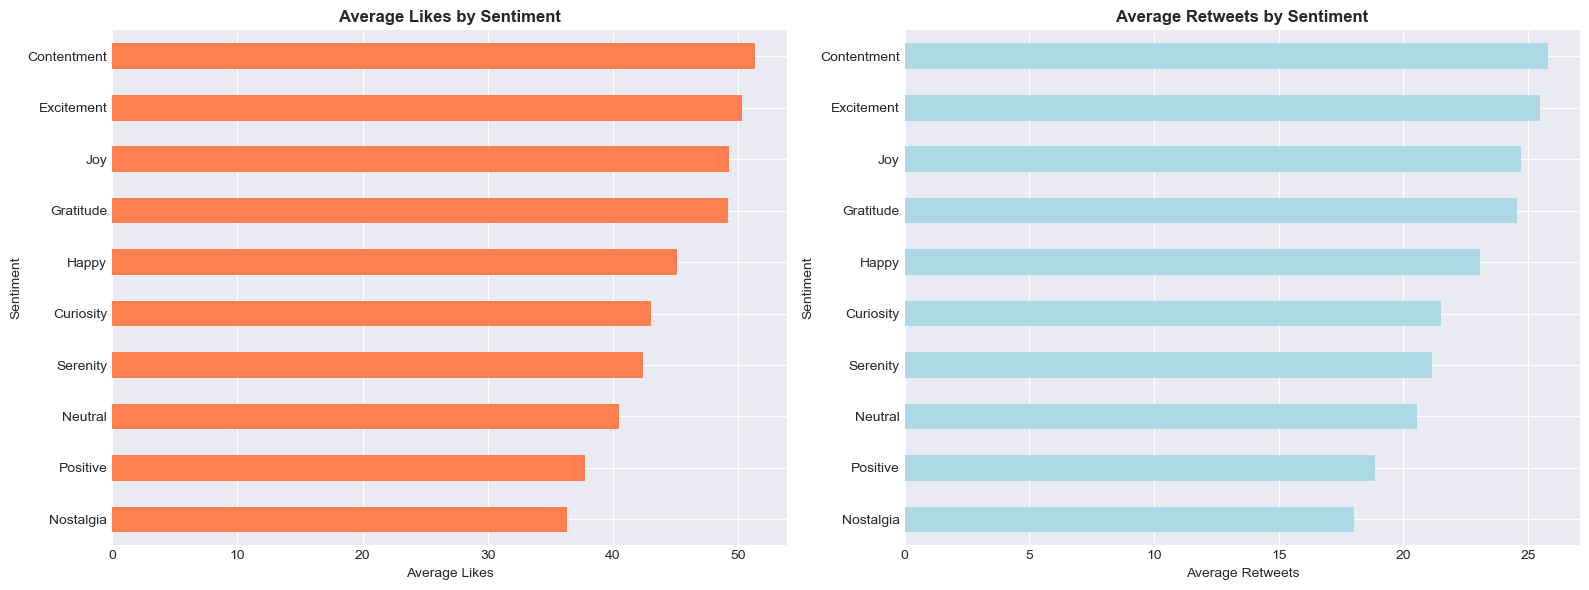

In [24]:
# Top 10 sentiments by average engagement
top_10_sentiments = sentiment_counts.head(10).index
df_top10 = df[df['Sentiment'].isin(top_10_sentiments)]

engagement_by_sentiment = df_top10.groupby('Sentiment')[['Likes', 'Retweets']].mean().sort_values('Likes', ascending=False)

print('Average Engagement by Top 10 Sentiments:')
print(engagement_by_sentiment.round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

engagement_by_sentiment['Likes'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Average Likes by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Likes')
axes[0].invert_yaxis()

engagement_by_sentiment['Retweets'].plot(kind='barh', ax=axes[1], color='lightblue')
axes[1].set_title('Average Retweets by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Retweets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Top 12 Countries by Post Count:
Country
USA               59
USA               55
UK                49
Canada            44
Australia         41
Canada            34
UK                33
India             21
USA               20
Canada            17
UK                13
Australia         12
Name: count, dtype: int64


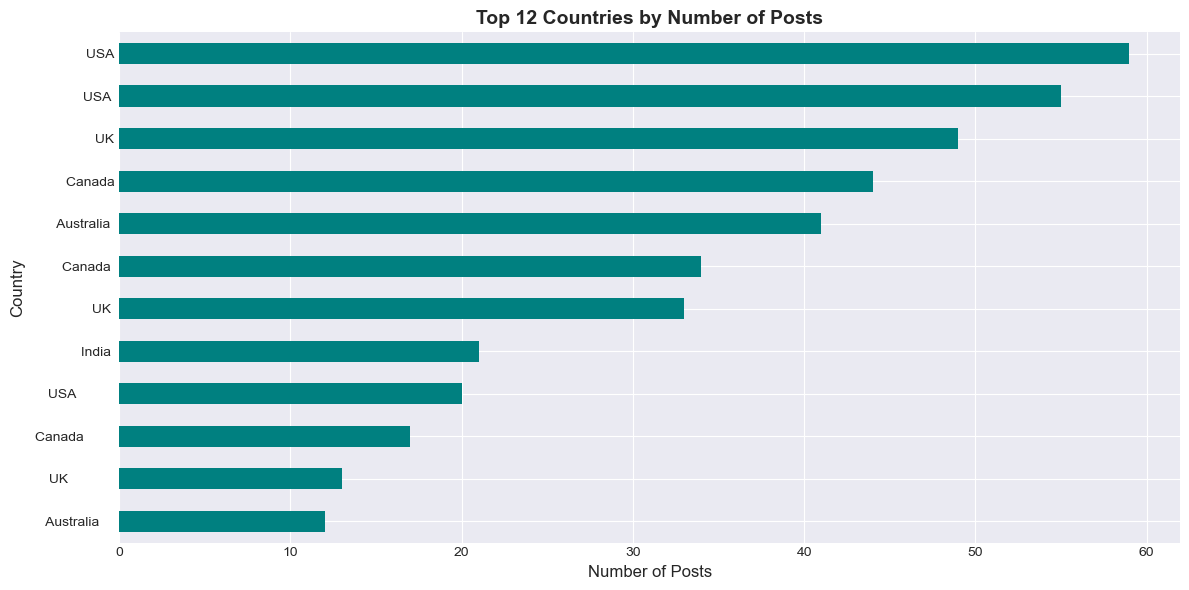

In [25]:
# Top countries by post count
top_countries = df['Country'].value_counts().head(12)

print('Top 12 Countries by Post Count:')
print(top_countries)

# Visualize
plt.figure(figsize=(12, 6))
top_countries.plot(kind='barh', color='teal')
plt.title('Top 12 Countries by Number of Posts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Posts', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Text Statistics:
Average text length: 84.43 characters
Average word count: 13.21 words
Max text length: 156 characters
Min text length: 27 characters


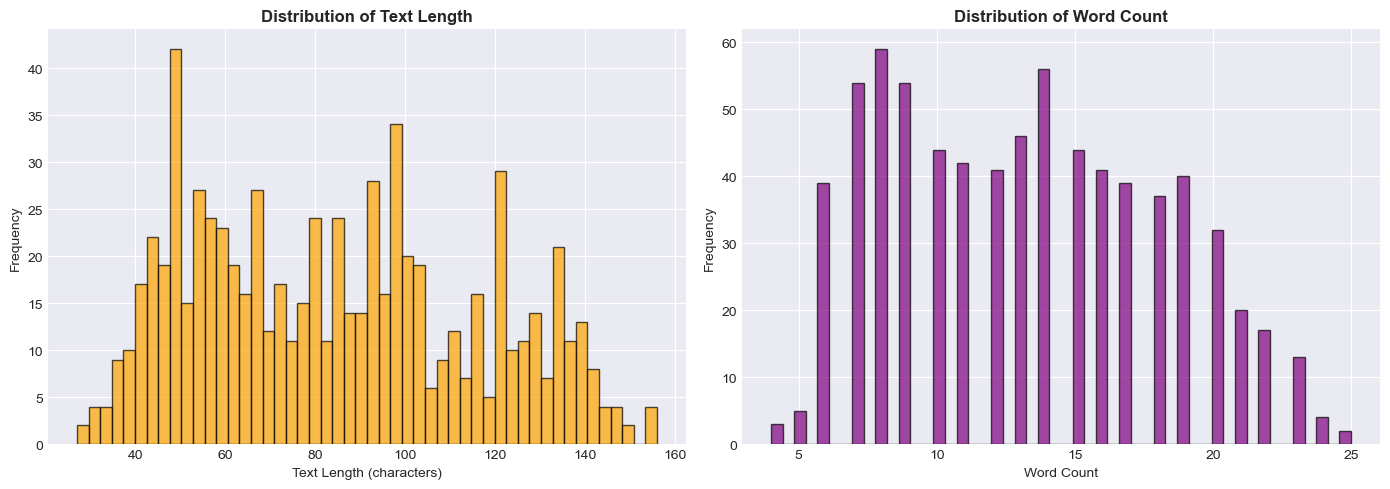

In [26]:
# Text length analysis
df['Text_Length'] = df['Text'].astype(str).apply(len)
df['Word_Count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

print('Text Statistics:')
print(f"Average text length: {df['Text_Length'].mean():.2f} characters")
print(f"Average word count: {df['Word_Count'].mean():.2f} words")
print(f"Max text length: {df['Text_Length'].max()} characters")
print(f"Min text length: {df['Text_Length'].min()} characters")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Text_Length'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Text Length', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Word_Count'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Posts by Year:
Year
2010      3
2011      4
2012      4
2013      4
2014      4
2015     19
2016     38
2017     43
2018     56
2019     73
2020     69
2021     63
2022     63
2023    289
Name: count, dtype: int64


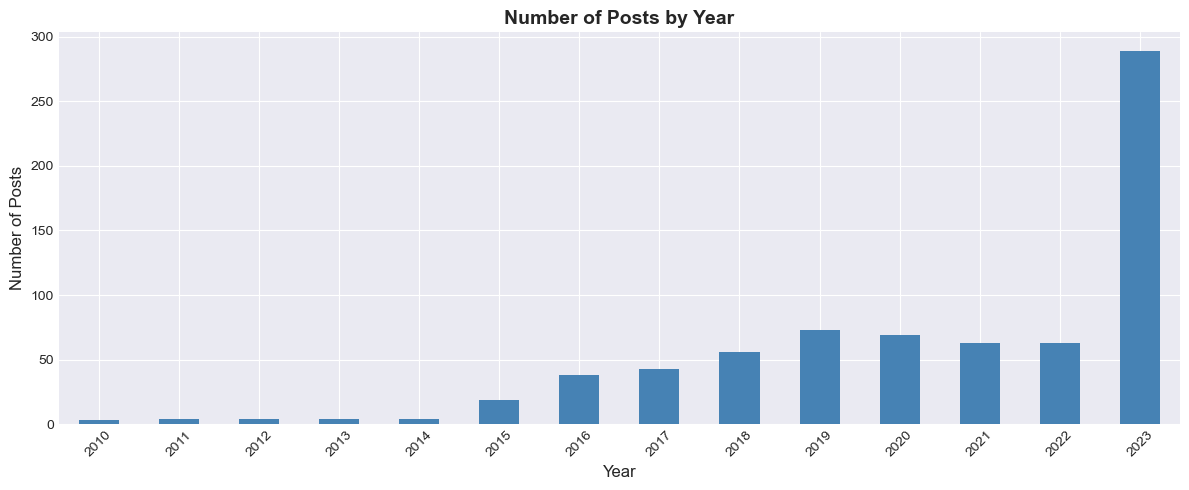

In [27]:
# Posts by year
posts_by_year = df['Year'].value_counts().sort_index()

print('Posts by Year:')
print(posts_by_year)

# Visualize
plt.figure(figsize=(12, 5))
posts_by_year.plot(kind='bar', color='steelblue')
plt.title('Number of Posts by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
def clean_text(text):
    """
    Clean and preprocess text data
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove mentions (@username)
    4. Remove hashtags (#hashtag)
    5. Remove special characters and numbers
    6. Remove extra whitespace
    """
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

In [29]:
# Apply text cleaning
print('Cleaning text data...')
df['Cleaned_Text'] = df['Text'].apply(clean_text)

# Show examples
print('\nOriginal vs Cleaned Text Examples:')
for i in range(5):
    print(f'\nExample {i+1}:')
    print(f'Original: {df["Text"].iloc[i]}')
    print(f'Cleaned:  {df["Cleaned_Text"].iloc[i]}')

# Remove empty texts
df = df[df['Cleaned_Text'].str.strip() != '']
print(f'\n✓ Dataset size after removing empty texts: {len(df):,}')

Cleaning text data...

Original vs Cleaned Text Examples:

Example 1:
Original: Enjoying a beautiful day at the park!
Cleaned:  enjoying a beautiful day at the park

Example 2:
Original: Traffic was terrible this morning.
Cleaned:  traffic was terrible this morning

Example 3:
Original: Just finished an amazing workout! 💪
Cleaned:  just finished an amazing workout

Example 4:
Original: Excited about the upcoming weekend getaway!
Cleaned:  excited about the upcoming weekend getaway

Example 5:
Original: Trying out a new recipe for dinner tonight.
Cleaned:  trying out a new recipe for dinner tonight

✓ Dataset size after removing empty texts: 732


In [30]:
# For modeling, let's focus on the most common sentiments
# This makes the classification task more manageable
top_n_sentiments = 10
top_sentiments_list = df['Sentiment'].value_counts().head(top_n_sentiments).index.tolist()

df_model = df[df['Sentiment'].isin(top_sentiments_list)].copy()

print(f'Selected top {top_n_sentiments} sentiments for modeling:')
print(df_model['Sentiment'].value_counts())
print(f'\nTotal samples for modeling: {len(df_model):,}')

Selected top 10 sentiments for modeling:
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Nostalgia      11
Name: count, dtype: int64

Total samples for modeling: 237


In [31]:
# Prepare features and target
X = df_model['Cleaned_Text']
y = df_model['Sentiment']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (237,)
Target shape: (237,)


In [32]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=3,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

# Transform text to TF-IDF features
print('Transforming text to TF-IDF features...')
X_tfidf = tfidf_vectorizer.fit_transform(X)

print(f'✓ TF-IDF matrix shape: {X_tfidf.shape}')
print(f'  Number of samples: {X_tfidf.shape[0]:,}')
print(f'  Number of features: {X_tfidf.shape[1]:,}')

Transforming text to TF-IDF features...
✓ TF-IDF matrix shape: (237, 179)
  Number of samples: 237
  Number of features: 179


In [33]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set size: {X_train.shape[0]:,} samples')
print(f'Testing set size: {X_test.shape[0]:,} samples')
print(f'\nTraining set sentiment distribution:')
print(y_train.value_counts())

Training set size: 189 samples
Testing set size: 48 samples

Training set sentiment distribution:
Sentiment
Positive       36
Joy            35
Excitement     30
Contentment    15
Gratitude      14
Neutral        14
Curiosity      13
Serenity       12
Happy          11
Nostalgia       9
Name: count, dtype: int64


In [34]:
# Train Random Forest Classifier
print('Training Random Forest Classifier...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

print('✓ Model trained successfully')

Training Random Forest Classifier...
✓ Model trained successfully


In [35]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

# Classification report
print('\nClassification Report:')
print('='*70)
print(classification_report(y_test, y_pred))

Model Accuracy: 0.6250 (62.50%)

Classification Report:
              precision    recall  f1-score   support

 Contentment       1.00      0.50      0.67         4
   Curiosity       1.00      0.67      0.80         3
  Excitement       0.83      0.71      0.77         7
   Gratitude       1.00      1.00      1.00         4
       Happy       0.33      0.33      0.33         3
         Joy       0.42      0.56      0.48         9
     Neutral       0.33      0.25      0.29         4
   Nostalgia       0.67      1.00      0.80         2
    Positive       0.55      0.67      0.60         9
    Serenity       1.00      0.67      0.80         3

    accuracy                           0.62        48
   macro avg       0.71      0.64      0.65        48
weighted avg       0.67      0.62      0.63        48



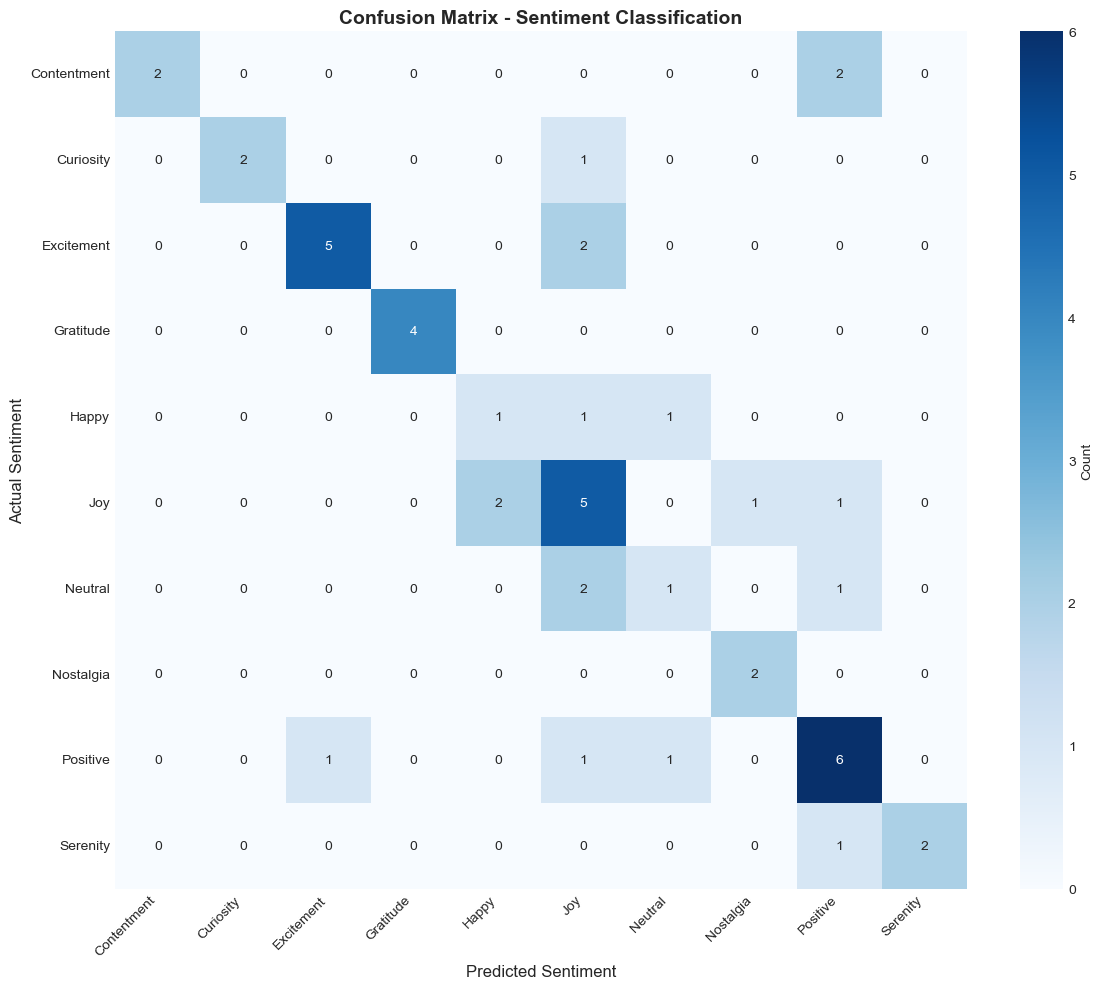

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sentiments = sorted(y_test.unique())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sentiments, yticklabels=sentiments,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Sentiment Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('Actual Sentiment', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Top 20 Most Important Features:
         feature  importance
141     serenity    0.043977
33   contentment    0.042223
72     gratitude    0.038274
39     curiosity    0.033156
52    excitement    0.023872
104          new    0.023061
106    nostalgia    0.017808
5            art    0.016323
107          old    0.015615
137       school    0.014165
61       feeling    0.013380
171      victory    0.013129
7       attended    0.012987
97      memories    0.012775
0      adventure    0.012420
6     attempting    0.011835
80       journey    0.011739
150      started    0.011449
40         dance    0.011423
149        spent    0.010941


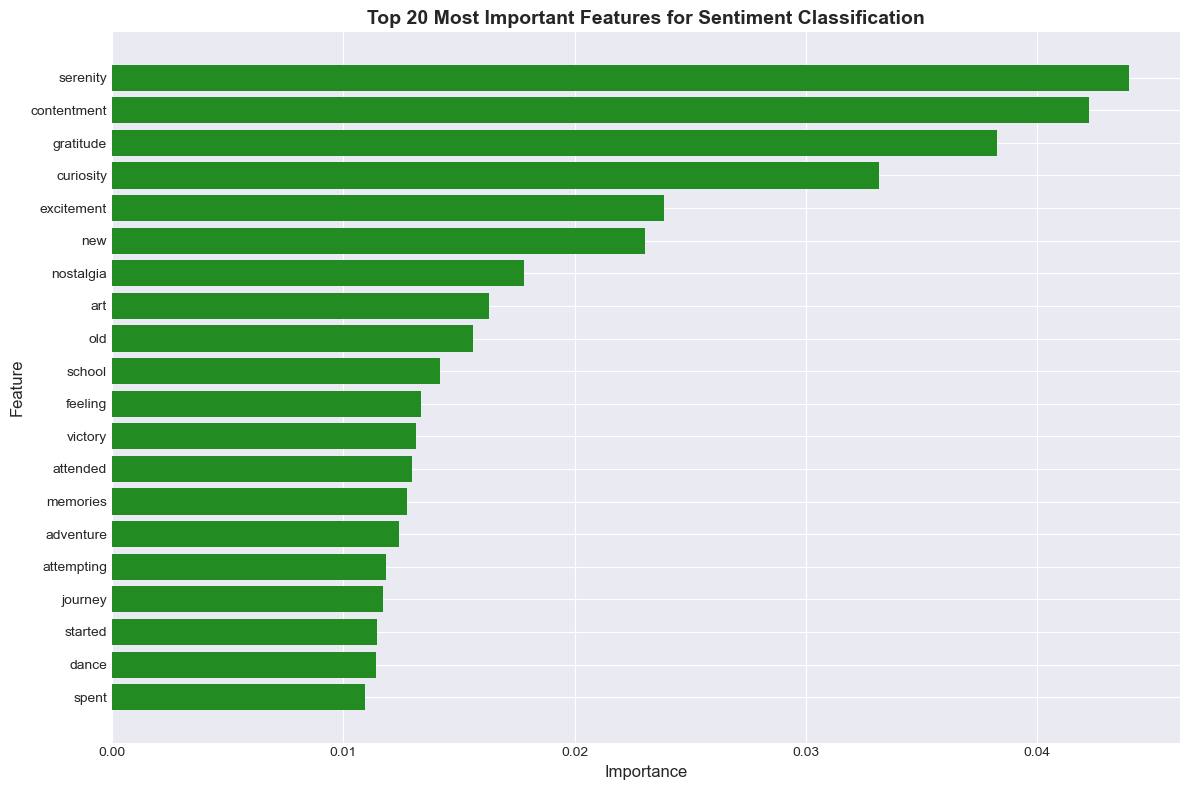

In [37]:
# Get feature names and importances
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

# Create DataFrame for easier analysis
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Display top 20 features
print('Top 20 Most Important Features:')
print(feature_importance_df.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(20)
plt.barh(top_features['feature'], top_features['importance'], color='forestgreen')
plt.title('Top 20 Most Important Features for Sentiment Classification', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# Test with sample texts
sample_texts = [
    "I am so happy and excited about this amazing news!",
    "This is absolutely terrible and disappointing.",
    "Feeling grateful for all the wonderful moments in life.",
    "Stuck in traffic again. So frustrating!",
    "Just finished an amazing workout session!"
]

print('Sample Predictions:')
print('='*70)
for text in sample_texts:
    cleaned = clean_text(text)
    vectorized = tfidf_vectorizer.transform([cleaned])
    prediction = rf_model.predict(vectorized)[0]
    probabilities = rf_model.predict_proba(vectorized)[0]
    confidence = probabilities.max()
    
    print(f'\nText: {text}')
    print(f'Predicted Sentiment: {prediction} (Confidence: {confidence:.2%})')

Sample Predictions:

Text: I am so happy and excited about this amazing news!
Predicted Sentiment: Positive (Confidence: 53.31%)

Text: This is absolutely terrible and disappointing.
Predicted Sentiment: Positive (Confidence: 53.31%)

Text: Feeling grateful for all the wonderful moments in life.
Predicted Sentiment: Positive (Confidence: 74.93%)

Text: Stuck in traffic again. So frustrating!
Predicted Sentiment: Positive (Confidence: 53.31%)

Text: Just finished an amazing workout session!
Predicted Sentiment: Positive (Confidence: 94.67%)
